# Day Results Discussion

This notebook is the next walkthrough in the sequence. It stays at the full-day level and asks a simple question: once the simulator has produced one full day of quarter-hour bins, how do the compared scenarios differ in power, slot pressure, and the chosen allocations?

The notebook is intentionally a checkpoint notebook. The aim here is to make the new JSON day-run outputs easy to read and compare. The final baseline framing can be added later. For now, the goal is to show that:

1. the same day demand is being solved in each scenario,
2. the resulting power traces can be compared on one shared bin axis,
3. the differences are tied back to concrete selected allocations rather than only aggregate curves.


## 1. Notebook Scope

The earlier notebooks already established the upstream pieces:

- the single-user layer produces a feasible cloud of operating choices,
- the joint TDMA layer chooses one exact row per user on a shared slot window,
- the day-cycle layer produces the sequence of quarter-hour user batches.

This notebook starts from the exported day-run JSON files and stays focused on interpretation. The code cells are kept short, and the repetitive loading, reshaping, table formatting, and plotting logic is moved into `helpers/day_results_helpers.py`.

At this stage, the notebook does not try to settle the final baseline argument. It only needs to show that the first end-to-end day outputs are structured, readable, and already useful for scenario comparison.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "main.py").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root(Path.cwd())
DOC_IMG_DIR = repo_root / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str((repo_root / "notebooks").resolve()))
sys.path.insert(0, str(repo_root.resolve()))
sys.path.insert(0, str((repo_root / "src").resolve()))

from helpers.DayCycleSimulationHelpers import export_doc_figure
from helpers.day_results_helpers import (
    build_allocation_choice_table,
    build_allocation_views_for_bin,
    build_binary_pa_bin_shape_table,
    build_binary_pa_classifier_table,
    build_binary_pa_distance_class_resource_table,
    build_binary_pa_feature_summary_table,
    build_binary_pa_multivariate_test_table,
    build_binary_pa_nearest_match_summary_table,
    build_binary_pa_nearest_match_table,
    build_binary_pa_univariate_test_table,
    build_bin_comparison_table,
    build_day_results_artifacts,
    build_filtered_500m_summary_table,
    build_standby_8w_user_profile_table,
    build_standby_hard_off_feature_test_table,
    build_standby_hard_off_group_shape_table,
    build_standby_hard_off_overlap_summary_table,
    build_standby_hard_off_8w_footprint_table,
    build_day_total_summary_table,
    build_infeasibility_boundary_table,
    filter_pa_choice_table_to_500m_user_bins,
    build_highlighted_bin_table,
    build_policy_summary_view_for_bin,
    build_reference_demand_table,
    build_scenario_pa_choice_table,
    pick_representative_bins,
    plot_cumulative_day_energy,
    plot_day_demand_context,
    plot_day_power_decomposition,
    plot_day_power_trajectories,
    plot_day_slot_pressure,
    plot_filtered_500m_shape_scatter,
    plot_pa_choice_load_scatter,
    plot_scenario_max_500m_rate_trace,
    plot_scenario_pa_choice_trace,
    plot_standby_hard_off_8w_footprint_scatter,
    plot_scenario_delta,
    style_allocation_choice_table,
    style_binary_pa_bin_shape_table,
    style_binary_pa_classifier_table,
    style_binary_pa_distance_class_resource_table,
    style_binary_pa_feature_summary_table,
    style_binary_pa_multivariate_test_table,
    style_binary_pa_nearest_match_summary_table,
    style_binary_pa_nearest_match_table,
    style_binary_pa_univariate_test_table,
    style_bin_comparison_table,
    style_day_total_summary_table,
    style_filtered_500m_summary_table,
    style_standby_8w_user_profile_table,
    style_standby_hard_off_feature_test_table,
    style_standby_hard_off_group_shape_table,
    style_standby_hard_off_overlap_summary_table,
    style_highlighted_bin_table,
    style_infeasibility_boundary_table,
    style_run_overview_table,
)
# Baseline-specific file loading and comparison plots can be added later once that scenario is defined.
from helpers.tdma_scheduling_helpers import plot_mcs_heatmaps, plot_power_heatmaps


## 2. Load the Compared Day Runs

The notebook expects one JSON object per scenario. Each file should follow the current `day_run_v1` export shape, including the day demand summary, the per-bin status, the schedule power fields, and the selected allocation rows.

Update the candidate file names below to point to the current exported runs. The notebook will load whichever scenario files already exist, so it can be used now with the hard-off export and later extended by adding the standby JSON.


In [2]:
CANDIDATE_SCENARIO_FILES = {
    "standby": [
        repo_root / "results" / "day_run_standby.json",
        repo_root / "results" / "day_runs" / "day_run_standby.json",
    ],
    "hard_off": [
        repo_root / "results" / "day_run_hard_off.json",
        repo_root / "results" / "day_run_result.json",
        repo_root / "results" / "day_runs" / "day_run_hard_off.json",
    ],
    # Baseline will be added once the fixed-policy comparator is defined.
}

SCENARIO_FILES = {}
for scenario_label, candidate_paths in CANDIDATE_SCENARIO_FILES.items():
    existing_path = next((path for path in candidate_paths if Path(path).exists()), None)
    if existing_path is not None:
        SCENARIO_FILES[scenario_label] = existing_path

if not SCENARIO_FILES:
    raise FileNotFoundError(
        "No day-run JSON files were found under results/. "
        "Update CANDIDATE_SCENARIO_FILES to point to the exported scenario files."
    )

artifacts = build_day_results_artifacts(SCENARIO_FILES)

scenario_order = artifacts["scenario_labels"]
reference_scenario = scenario_order[0]
comparison_scenario = scenario_order[1] if len(scenario_order) > 1 else scenario_order[0]
comparison_available = len(scenario_order) > 1
hard_off_scenario = "hard_off" if "hard_off" in scenario_order else reference_scenario

bin_table_all = artifacts["bin_table_all"]
demand_user_table_all = artifacts["demand_user_table_all"]
allocation_table_all = artifacts["allocation_table_all"]
run_overview_table = artifacts["run_overview_table"]
bin_duration_s = float(artifacts["bin_duration_s"])

reference_demand_table = build_reference_demand_table(
    bin_table_all,
    reference_scenario=reference_scenario,
)

display(
    style_run_overview_table(
        run_overview_table,
        caption="Compared day-run exports",
    )
)

if not comparison_available:
    print(
        "Only one scenario JSON is available right now. "
        "Add the standby export later to enable direct cross-scenario delta plots."
    )


Scenario,Switch policy,Load curve,Quarter-hour bins,Solved bins,Infeasible bins,Mean total power (W),Peak total power (W),Day energy (Wh)
standby,standby,half_load_curve.csv,96,94,2,25.52,64.15,599.81
hard_off,hard_off,half_load_curve.csv,96,94,2,12.10,62.88,284.29


The table above is only a compact run overview, but it already shows the key point: the notebook is no longer reading ad hoc prints. It is reading one structured day result per scenario, with enough detail to compare both the day totals and the per-bin behavior.


## 3. Shared Day Demand Context

Before comparing scenarios, it helps to anchor the day itself. The two plots below use the demand fields from one reference scenario. Those values should be identical across scenarios because the day demand is fixed before the solver is run.

The first panel shows the total requested rate in each quarter-hour bin. The second panel shows the active user count seen by the scheduler in the same bins.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_demand_context.png


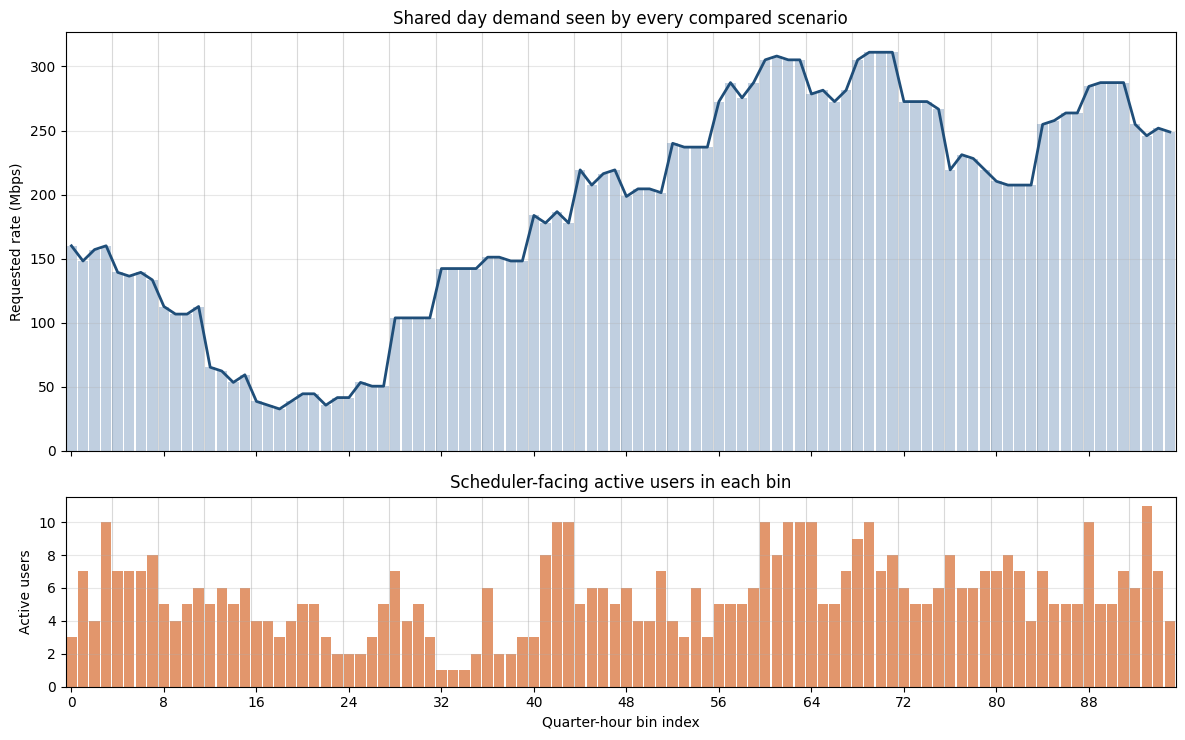

In [3]:
fig, axes = plot_day_demand_context(reference_demand_table)
export_doc_figure(fig, "day_results_demand_context.png", DOC_IMG_DIR)
plt.show()


## 4. Day-Level Power Traces

The next step is to place the compared scenarios on the same day axis. The first figure shows the total PA DC power in each bin. The second figure separates that total into active and inactive contributions.

This split is useful because it makes the switch-policy effect visible in a direct way. It also shows whether two scenarios differ mainly because they choose different active rows or because they pay a different inactive power penalty.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_total_power_over_time.png


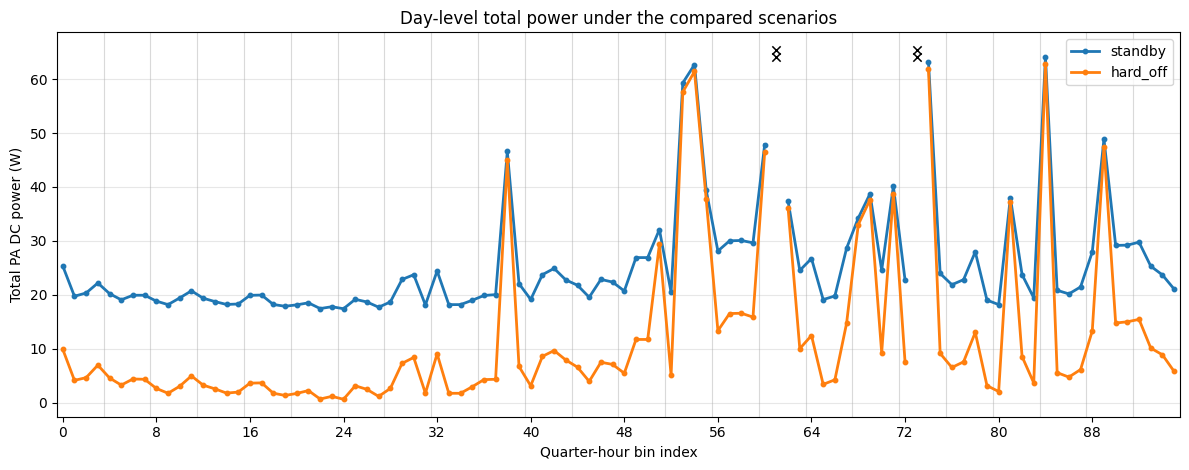

In [4]:
fig, ax = plot_day_power_trajectories(
    bin_table_all,
    scenario_order=scenario_order,
)
export_doc_figure(fig, "day_results_total_power_over_time.png", DOC_IMG_DIR)
plt.show()


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_power_decomposition_over_time.png


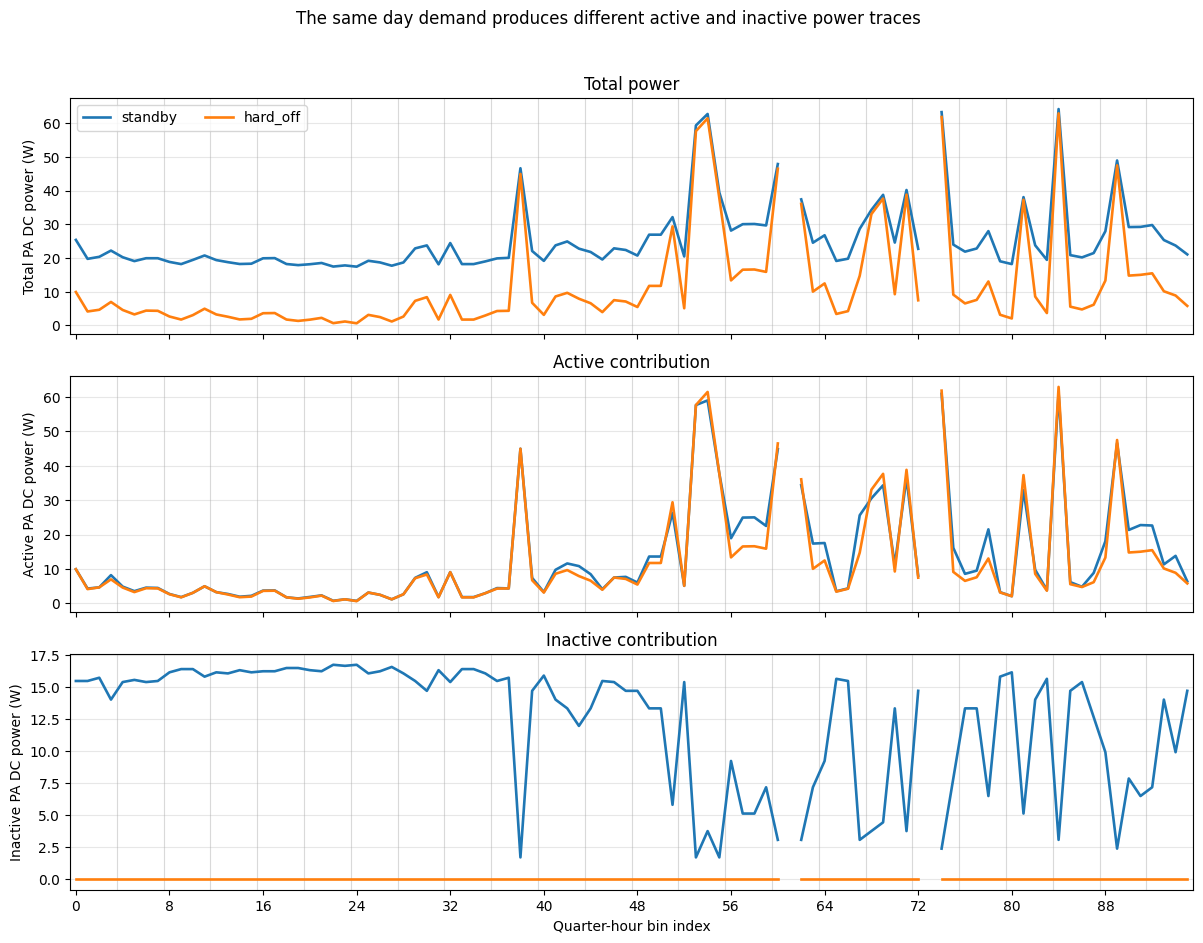

In [5]:
fig, axes = plot_day_power_decomposition(
    bin_table_all,
    scenario_order=scenario_order,
)
export_doc_figure(fig, "day_results_power_decomposition_over_time.png", DOC_IMG_DIR)
plt.show()


The main checkpoint claim is already visible here: the same day demand does not produce one fixed power trajectory. The scenario assumption changes the trace, and the active versus inactive split shows where that difference comes from.


Total bin load alone does not fully explain the hard-off PA switch. The next figure therefore focuses on the portion of demand that comes from users at distances of at least 300 m. Each bin is colored by the selected PA family, and infeasible bins are marked separately.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_hard_off_far_user_pressure.png


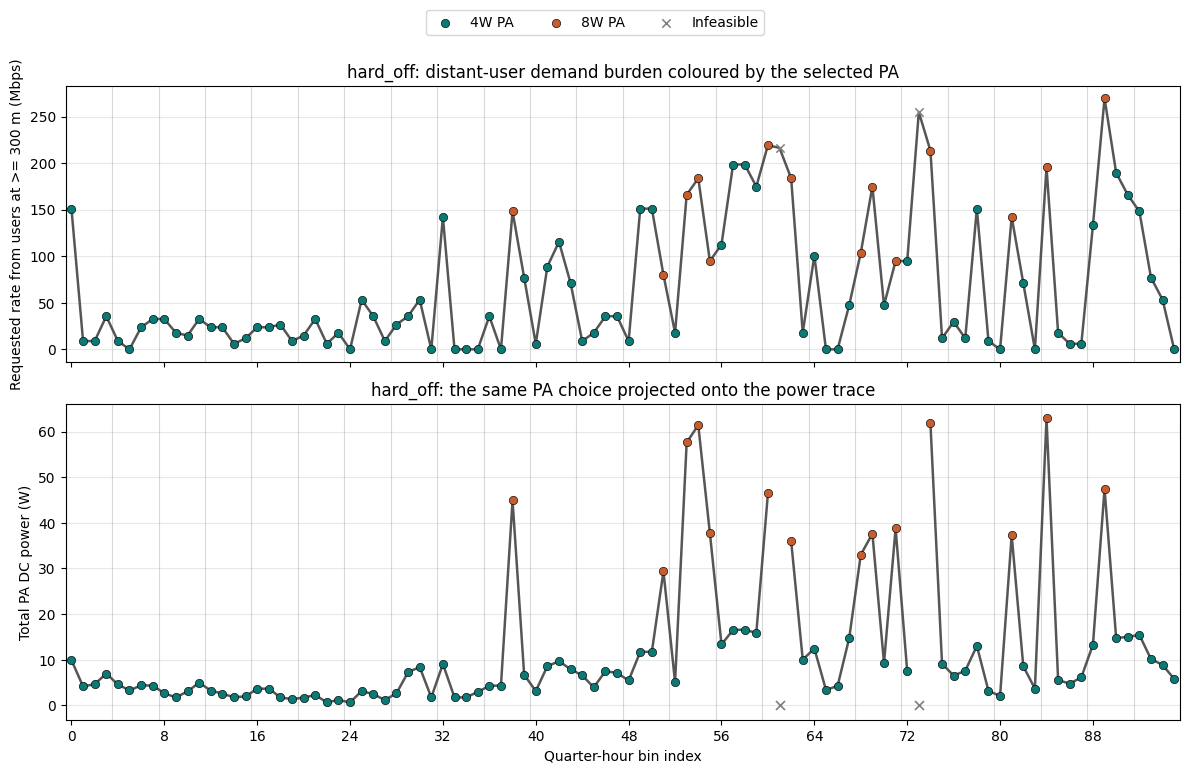

In [6]:
hard_off_pa_choice_table = build_scenario_pa_choice_table(
    allocation_table_all,
    bin_table_all,
    scenario_label=hard_off_scenario,
    pa_label_map=artifacts["scenario_runs"][hard_off_scenario]["pa_label_map"],
)

fig, axes = plot_scenario_pa_choice_trace(
    hard_off_pa_choice_table,
    scenario_label=hard_off_scenario,
)
export_doc_figure(fig, "day_results_hard_off_far_user_pressure.png", DOC_IMG_DIR)
plt.show()


The two companion plots below sharpen the same question from different angles. The first tracks the strongest user at 500 m in each bin. The second places each bin in total-load versus distant-load space so that the 4 W, 8 W, and infeasible bins can be compared directly.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_hard_off_max_500m_rate.png


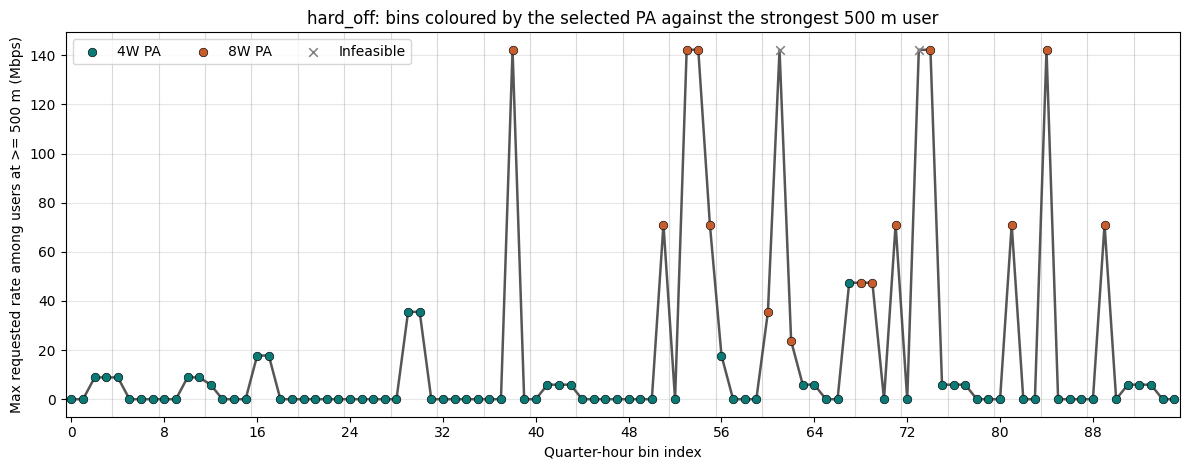

In [7]:
fig, ax = plot_scenario_max_500m_rate_trace(
    hard_off_pa_choice_table,
    scenario_label=hard_off_scenario,
)
export_doc_figure(fig, "day_results_hard_off_max_500m_rate.png", DOC_IMG_DIR)
plt.show()


Filtering to bins with at least one 500 m user removes the easy cases. The next table and scatter then split the distant-user burden into two parts: what sits at 500 m or beyond, and what still sits in the 300-499 m band.

This is the most direct first check of what distinguishes the hard-off bins that stay on the 4 W PA, the bins that switch to 8 W, and the bins that become infeasible.


In [8]:
filtered_500m_pa_choice_table = filter_pa_choice_table_to_500m_user_bins(
    hard_off_pa_choice_table
)
filtered_500m_summary_table = build_filtered_500m_summary_table(
    filtered_500m_pa_choice_table
)
display(
    style_filtered_500m_summary_table(
        filtered_500m_summary_table,
        caption="Hard-off bins with at least one 500 m user",
    )
)


PA choice,Bins,Mean total load (Mbps),Mean load from 500 m+ users (Mbps),Mean load from 300-499 m users (Mbps),Mean max 500 m user (Mbps)
4W PA,23,182.93,13.40,41.35,12.50
8W PA,14,258.62,95.66,66.46,87.20
Infeasible,2,290.37,207.41,28.15,142.22


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_hard_off_500m_filtered_shape.png


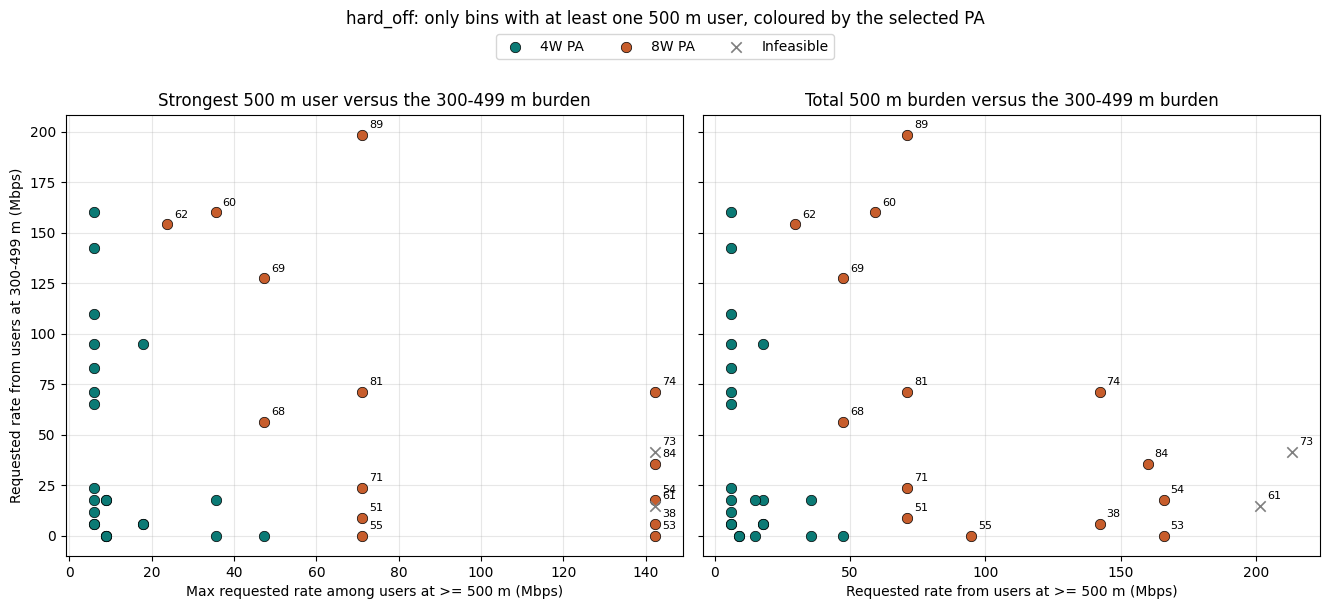

In [9]:
fig, axes = plot_filtered_500m_shape_scatter(
    filtered_500m_pa_choice_table,
    scenario_label=hard_off_scenario,
)
export_doc_figure(fig, "day_results_hard_off_500m_filtered_shape.png", DOC_IMG_DIR)
plt.show()


The filtered plot suggests two distinct numerical questions. First, is infeasibility separated by the total demand placed on `>= 500 m` users? Second, among the solved bins with a `500 m` user, how well can the `4 W` and `8 W` choices be separated numerically?

The tables below answer those questions with explicit summary statistics and simple classification models. The leave-one-out (`LOO`) accuracy is included so that the separation is not judged only on the same bins used to fit the rule.


In [10]:
infeasibility_boundary_table = build_infeasibility_boundary_table(
    filtered_500m_pa_choice_table
)
binary_pa_feature_summary_table = build_binary_pa_feature_summary_table(
    filtered_500m_pa_choice_table
)
binary_pa_univariate_test_table = build_binary_pa_univariate_test_table(
    filtered_500m_pa_choice_table
)

display(
    style_infeasibility_boundary_table(
        infeasibility_boundary_table,
        caption="Infeasible bins are separated by the total load placed on >= 500 m users",
    )
)
display(
    style_binary_pa_feature_summary_table(
        binary_pa_feature_summary_table,
        caption="Solved bins with a 500 m user: class summaries for the 4 W and 8 W choices",
    )
)
display(
    style_binary_pa_univariate_test_table(
        binary_pa_univariate_test_table,
        caption="Solved bins with a 500 m user: univariate Mann-Whitney tests",
    )
)


Feasible bins,Infeasible bins,Feasible median load from >= 500 m users (Mbps),Infeasible median load from >= 500 m users (Mbps),Feasible max load from >= 500 m users (Mbps),Infeasible min load from >= 500 m users (Mbps),Separation gap (Mbps)
37,2,17.78,207.41,165.93,201.48,35.56


Feature,4W PA bins,4W PA mean,4W PA median,4W PA std,8W PA bins,8W PA mean,8W PA median,8W PA std
Load from >= 500 m users (Mbps),23,13.40,5.93,11.54,14,95.66,71.11,48.91
Load from 300-499 m users (Mbps),23,41.35,17.78,49.90,14,66.46,45.93,67.19


Feature,Mann-Whitney U,Two-sided p-value
Load from >= 500 m users (Mbps),4.0,5.879e-07
Load from 300-499 m users (Mbps),123.0,2.374e-01


In [11]:
binary_pa_multivariate_test_table = build_binary_pa_multivariate_test_table(
    filtered_500m_pa_choice_table
)
binary_pa_classifier_table = build_binary_pa_classifier_table(
    filtered_500m_pa_choice_table
)

display(
    style_binary_pa_multivariate_test_table(
        binary_pa_multivariate_test_table,
        caption="Solved bins with a 500 m user: two-feature multivariate separation and LDA weights",
    )
)
display(
    style_binary_pa_classifier_table(
        binary_pa_classifier_table,
        caption="Solved bins with a 500 m user: simple classifiers compared on leave-one-out accuracy",
    )
)


4W bins,8W bins,Hotelling T^2,F statistic,p-value,LDA weight on >= 500 m load,LDA weight on 300-499 m load,Relative weight >= 500 m / 300-499 m,LDA threshold
23,14,94.16,45.74,2.291e-10,0.119,0.039,3.03,9.138


Classifier,Decision rule,Training accuracy,LOO accuracy,4W PA -> 4W PA,4W PA -> 8W PA,8W PA -> 4W PA,8W PA -> 8W PA
Max single-user rate at >= 500 m,Predict 8W PA when max_requested_rate_500m_plus_mbps >= 20.74,0.919,0.865,20,3,2,12
Total load from >= 500 m users,Predict 8W PA when requested_rate_500m_plus_mbps >= 41.48,0.946,0.892,20,3,1,13
Two-feature LDA,Predict 8W PA when 3.03 * load_500m_plus + 1.00 * load_300_499m > 231.69,0.946,0.919,23,0,3,11


Read these numerical checks in three steps. If the infeasible minimum exceeds the feasible maximum on the `>= 500 m` load axis, then the current run contains an empirical feasibility threshold for that far-user burden. For the solved `4 W` and `8 W` bins, the univariate test table shows whether each axis separates the classes on its own, while the multivariate and classifier tables show whether a two-feature rule improves the classification once both axes are used together.

This matters because the leave-one-out accuracy can be compared directly across the simple rules. If the two-feature discriminator only improves a little over the best one-dimensional threshold, then the dominant driver is still the `>= 500 m` load, with the `300–499 m` load mainly refining borderline cases rather than defining a wholly independent mechanism.


The current day JSON cannot generate synthetic counterfactual bins, but it can still support two useful observational checks. First, it can show which distance classes consume the slot and active-power budget inside the solved `4 W` and `8 W` bins. Second, it can compare each solved `8 W` bin against the nearest solved `4 W` bin at almost the same total load, which is the closest post-hoc approximation to holding aggregate demand fixed while varying the geometry of that demand.


In [12]:
binary_pa_bin_shape_table = build_binary_pa_bin_shape_table(
    filtered_500m_pa_choice_table,
    demand_user_table_all,
)
binary_pa_distance_class_resource_table = build_binary_pa_distance_class_resource_table(
    filtered_500m_pa_choice_table,
    demand_user_table_all,
    allocation_table_all,
)

display(
    style_binary_pa_bin_shape_table(
        binary_pa_bin_shape_table,
        caption="Solved hard-off bins with a 500 m user: average bin shape by PA choice",
    )
)
display(
    style_binary_pa_distance_class_resource_table(
        binary_pa_distance_class_resource_table,
        caption="Solved hard-off bins with a 500 m user: distance-class demand, slot, and active-power shares",
    )
)


PA choice,Bins,Mean total load (Mbps),Mean >= 500 m load (Mbps),Mean 300-499 m load (Mbps),Mean far-user count,Mean mid-user count,Mean near-user count,Median far demand share,Median mid demand share
4W PA,23,182.93,13.40,41.35,1.13,1.52,4.22,0.057,0.158
8W PA,14,258.62,95.66,66.46,1.43,1.64,3.57,0.348,0.162


PA choice,Distance class,Bins,Demand total (Mbps),Demand share,Delivered total (Mbps),Slot total,Slot share,Active DC total (W),Active DC share,Slots per demanded Mbps,Active DC W per demanded Mbps,Slot-share / demand-share,DC-share / demand-share
4W PA,Near (<300 m),23,2948.15,0.701,3215.17,188,0.478,73.24,0.383,0.064,0.025,0.683,0.547
4W PA,Mid (300-499 m),23,951.11,0.226,962.85,115,0.293,65.12,0.341,0.121,0.068,1.294,1.508
4W PA,Far (>=500 m),23,308.15,0.073,310.78,90,0.229,52.68,0.276,0.292,0.171,3.127,3.765
8W PA,Near (<300 m),14,1351.11,0.373,1859.12,64,0.230,88.19,0.139,0.047,0.065,0.617,0.374
8W PA,Mid (300-499 m),14,930.37,0.257,944.19,55,0.198,116.88,0.185,0.059,0.126,0.770,0.719
8W PA,Far (>=500 m),14,1339.26,0.370,1353.30,159,0.572,427.30,0.676,0.119,0.319,1.546,1.827


In [13]:
binary_pa_nearest_match_table = build_binary_pa_nearest_match_table(
    filtered_500m_pa_choice_table,
    demand_user_table_all,
)
binary_pa_nearest_match_summary_table = build_binary_pa_nearest_match_summary_table(
    binary_pa_nearest_match_table
)

display(
    style_binary_pa_nearest_match_summary_table(
        binary_pa_nearest_match_summary_table,
        caption="Nearest total-load matches: how the solved 8 W bins differ from solved 4 W bins at similar aggregate demand",
    )
)
display(
    style_binary_pa_nearest_match_table(
        binary_pa_nearest_match_table,
        caption="Per-bin nearest total-load match for each solved hard-off 8 W bin",
    )
)


Matched pairs,Mean absolute total-load difference (Mbps),Median absolute total-load difference (Mbps),Mean increase in >= 500 m load (Mbps),Median increase in >= 500 m load (Mbps),Mean increase in 300-499 m load (Mbps),Median increase in 300-499 m load (Mbps)
14,4.66,5.93,88.68,65.19,23.07,11.85


8W PA bin,4W PA match,Absolute total-load difference (Mbps),8W PA >= 500 m load (Mbps),4W PA >= 500 m load (Mbps),8W PA 300-499 m load (Mbps),4W PA 300-499 m load (Mbps),Increase in >= 500 m load (Mbps),Increase in 300-499 m load (Mbps),8W PA far-user count,4W PA far-user count,8W PA mid-user count,4W PA mid-user count
62,63,0.00,29.63,5.93,154.07,11.85,23.70,142.22,2,1,3,2
68,63,0.00,47.41,5.93,56.30,11.85,41.48,44.44,1,1,2,2
89,91,0.00,71.11,5.93,198.52,160.00,65.19,38.52,1,1,3,2
74,56,0.00,142.22,17.78,71.11,94.81,124.44,-23.70,1,1,1,1
60,63,0.00,59.26,5.93,160.00,11.85,53.33,148.15,2,1,4,2
84,92,0.00,160.00,5.93,35.56,142.22,154.07,-106.67,2,1,2,1
55,77,5.93,94.81,5.93,0.00,5.93,88.89,-5.93,2,1,0,1
53,77,5.93,165.93,5.93,0.00,5.93,160.00,-5.93,2,1,0,1
71,63,5.93,71.11,5.93,23.70,11.85,65.19,11.85,1,1,1,2
69,63,5.93,47.41,5.93,127.41,11.85,41.48,115.56,1,1,3,2


Read these observational tables with two questions in mind. If a distance class carries a much larger share of slots or active DC power than its share of requested rate, then that class is consuming scheduler resources disproportionately. The nearest-match table then asks a narrower question: once total load is held roughly constant, does the `8 W` bin still carry materially more `>= 500 m` load, materially more `300–499 m` load, or both?


Standby changes the interpretation slightly because it often mixes `4 W` and `8 W` users inside the same solved bin. The next tables therefore shift the question from a whole-bin label to a user-footprint question: which users receive the `8 W` PA in standby, and does that standby `8 W` footprint line up with the bins that become pure `8 W` under `hard_off`?


In [ ]:
standby_hard_off_8w_footprint_table = pd.DataFrame()

if {"standby", hard_off_scenario}.issubset(set(scenario_order)):
    standby_8w_user_profile_table = build_standby_8w_user_profile_table(
        allocation_table_all,
        demand_user_table_all,
        scenario_label="standby",
    )
    standby_hard_off_8w_footprint_table = build_standby_hard_off_8w_footprint_table(
        allocation_table_all,
        demand_user_table_all,
        hard_off_pa_choice_table,
        standby_label="standby",
    )
    standby_hard_off_overlap_summary_table = build_standby_hard_off_overlap_summary_table(
        standby_hard_off_8w_footprint_table
    )

    display(
        style_standby_8w_user_profile_table(
            standby_8w_user_profile_table,
            caption="Standby allocations that use the 8W PA: which distance classes receive it?",
        )
    )
    display(
        style_standby_hard_off_overlap_summary_table(
            standby_hard_off_overlap_summary_table,
            caption="Standby bins with any 8W user versus hard-off bins that become pure 8W",
        )
    )
else:
    print("Add both standby and hard-off JSON exports to enable the cross-scenario 8W footprint comparison.")


In [ ]:
if not standby_hard_off_8w_footprint_table.empty:
    fig, ax = plot_standby_hard_off_8w_footprint_scatter(
        standby_hard_off_8w_footprint_table
    )
    export_doc_figure(fig, "day_results_standby_8w_overlap_scatter.png", DOC_IMG_DIR)
    plt.show()

    standby_hard_off_group_shape_table = build_standby_hard_off_group_shape_table(
        standby_hard_off_8w_footprint_table
    )
    standby_hard_off_feature_test_table = build_standby_hard_off_feature_test_table(
        standby_hard_off_8w_footprint_table
    )

    display(
        style_standby_hard_off_group_shape_table(
            standby_hard_off_group_shape_table,
            caption="Standby bins that assign 8W: the user footprint grouped by the hard-off outcome",
        )
    )
    display(
        style_standby_hard_off_feature_test_table(
            standby_hard_off_feature_test_table,
            caption="Standby 8W footprint features that separate hard-off 8W overlap bins from standby-only 8W bins",
        )
    )


This comparison sharpens the story. In the current run, every hard-off `8 W` bin already contains at least one standby `8 W` user, but the reverse is not true because standby also assigns `8 W` in many bins that remain whole-bin `4 W` under hard-off. The separating feature is the standby `8 W` far-user burden itself: bins that later become hard-off `8 W` already assign a substantial share of their standby `8 W` load to `>= 500 m` users, while the standby-only `8 W` bins allocate most of their standby `8 W` load to near and mid users instead.


## 5. Slot Pressure and Remaining Headroom

Power differences are easier to read when they are placed next to slot pressure. The next figure therefore tracks the used slots and the remaining unused slots across the same day.

This is not yet a full saturation analysis. It is simply the cleanest first view of when the scheduler is under pressure and when it still has room to move.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_slot_pressure.png


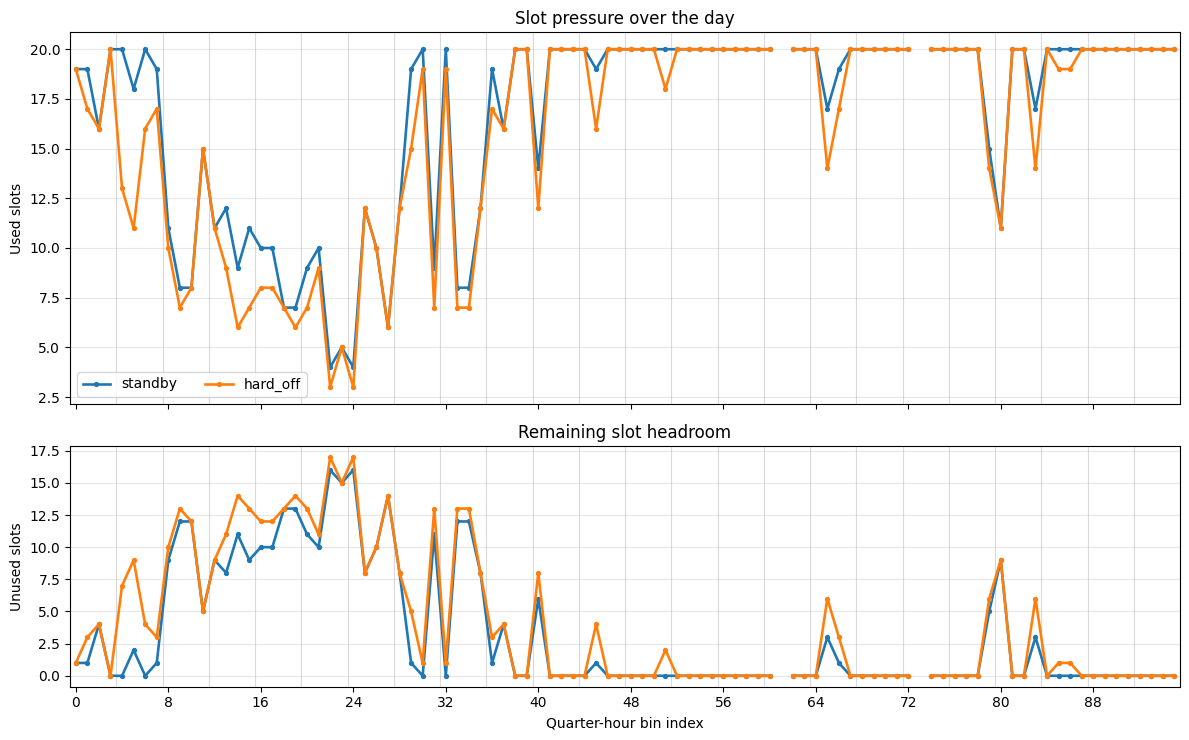

In [14]:
fig, axes = plot_day_slot_pressure(
    bin_table_all,
    scenario_order=scenario_order,
)
export_doc_figure(fig, "day_results_slot_pressure.png", DOC_IMG_DIR)
plt.show()


## 6. Pick a Small Set of Representative Bins

The day plots show where the traces rise and, once multiple scenarios are loaded, where they diverge. To keep the discussion concrete, the notebook highlights a small set of bins:

- one quiet period,
- one peak period,
- one bin with the largest total-power gap between the reference scenario and one comparison scenario, when that comparison is available.

Only two of those bins are unpacked in detail below. That is enough for a checkpoint notebook and avoids turning the discussion into a plot dump.


In [15]:
highlighted_bins = pick_representative_bins(
    bin_table_all,
    reference_scenario=reference_scenario,
    comparison_scenario=comparison_scenario,
)

QUIET_BIN = highlighted_bins["quiet_bin"]
PEAK_BIN = highlighted_bins["peak_bin"]
DIVERGENCE_BIN = highlighted_bins["divergence_bin"]
DETAIL_BIN = DIVERGENCE_BIN if comparison_available else PEAK_BIN
DETAIL_BIN_LABEL = "largest scenario gap" if comparison_available else "peak period"

highlighted_bin_table = build_highlighted_bin_table(
    bin_table_all,
    reference_scenario=reference_scenario,
    highlighted_bins=highlighted_bins,
)

display(
    style_highlighted_bin_table(
        highlighted_bin_table,
        caption="Highlighted bins used in the walkthrough",
    )
)


Role,Bin index,Clock,Users,Requested rate (Mbps),Used slots,Unused slots
Quiet period,18,04:30,3,32.59,7,13
Peak period,69,17:15,10,311.11,20,0
Largest scenario gap,24,06:00,2,41.48,4,16


## 7. One Quiet Bin

The first detailed example uses the quiet bin. This is the simplest place to see what a day-level solution actually contains: the bin status, the delivered rate, the total power, and the selected allocations for each compared scenario.

The two tables below therefore keep the view compact. The first table summarizes the bin-level outcome. The second table shows the selected rows that generated that outcome.


In [16]:
quiet_bin_summary = build_bin_comparison_table(
    bin_table_all,
    scenario_order=scenario_order,
    bin_index=QUIET_BIN,
)
quiet_bin_allocations = build_allocation_choice_table(
    allocation_table_all,
    scenario_order=scenario_order,
    bin_index=QUIET_BIN,
)

display(
    style_bin_comparison_table(
        quiet_bin_summary,
        caption=f"Bin-level comparison for quiet bin {QUIET_BIN}",
    )
)
display(
    style_allocation_choice_table(
        quiet_bin_allocations,
        caption=f"Selected allocations for quiet bin {QUIET_BIN}",
    )
)


Scenario,Status,Outcome,Users,Requested rate (Mbps),Delivered rate (Mbps),Total power (W),Active power (W),Inactive power (W),Used slots,Unused slots
standby,solved,solved,3,32.59,32.98,18.21,1.76,16.46,7,13
hard_off,solved,solved,3,32.59,32.98,1.76,1.76,0.00,7,13


Scenario,User id,PA,Bandwidth (MHz),PRBs,Layers,MCS,Slots,Delivered rate (Mbps),Avg frame DC power (W),Avg frame RF power (W)
standby,154,4W PA,100,276,1,12,2,8.98,0.52,0.08
standby,236,4W PA,100,261,1,15,1,6.03,0.19,0.02
standby,285,4W PA,100,276,1,12,4,17.97,1.05,0.17
hard_off,154,4W PA,100,276,1,12,2,8.98,0.52,0.08
hard_off,236,4W PA,100,261,1,15,1,6.03,0.19,0.02
hard_off,285,4W PA,100,276,1,12,4,17.97,1.05,0.17


Even at low demand, the notebook is already doing something useful: it ties the day-level trace back to the exact selected rows. This makes it possible to discuss not just how much power was used, but how the scheduler chose to provide the required rate in that bin.


## 8. One High-Pressure Bin

The next detailed example uses one stressed bin. When multiple scenarios are loaded, this is the bin with the largest total-power difference between the reference scenario and one comparison scenario. Until then, the notebook falls back to the peak-demand bin so that the same schedule-reading workflow can still be checked.

Again, the discussion starts with the compact tables. After that, the notebook reuses the TDMA heatmap views from the earlier scheduling notebook so that the compared allocations can be read on the same resource-grid vocabulary as before.


In [17]:
detail_bin_summary = build_bin_comparison_table(
    bin_table_all,
    scenario_order=scenario_order,
    bin_index=DETAIL_BIN,
)
detail_bin_allocations = build_allocation_choice_table(
    allocation_table_all,
    scenario_order=scenario_order,
    bin_index=DETAIL_BIN,
)

display(
    style_bin_comparison_table(
        detail_bin_summary,
        caption=f"Bin-level comparison for {DETAIL_BIN_LABEL} bin {DETAIL_BIN}",
    )
)
display(
    style_allocation_choice_table(
        detail_bin_allocations,
        caption=f"Selected allocations for {DETAIL_BIN_LABEL} bin {DETAIL_BIN}",
    )
)


Scenario,Status,Outcome,Users,Requested rate (Mbps),Delivered rate (Mbps),Total power (W),Active power (W),Inactive power (W),Used slots,Unused slots
standby,solved,solved,2,41.48,55.61,17.43,0.72,16.71,4,16
hard_off,solved,solved,2,41.48,53.18,0.64,0.64,0.00,3,17


Scenario,User id,PA,Bandwidth (MHz),PRBs,Layers,MCS,Slots,Delivered rate (Mbps),Avg frame DC power (W),Avg frame RF power (W)
standby,39,4W PA,100,276,4,20,1,35.21,0.13,0.01
standby,265,4W PA,100,276,1,17,3,20.40,0.59,0.07
hard_off,39,4W PA,100,276,4,20,1,35.21,0.13,0.01
hard_off,265,4W PA,100,276,2,12,2,17.97,0.51,0.08


C:\Users\henry\Documents\Masters Thesis\code\notebooks\helpers\tdma_scheduling_helpers.py:822: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 1))


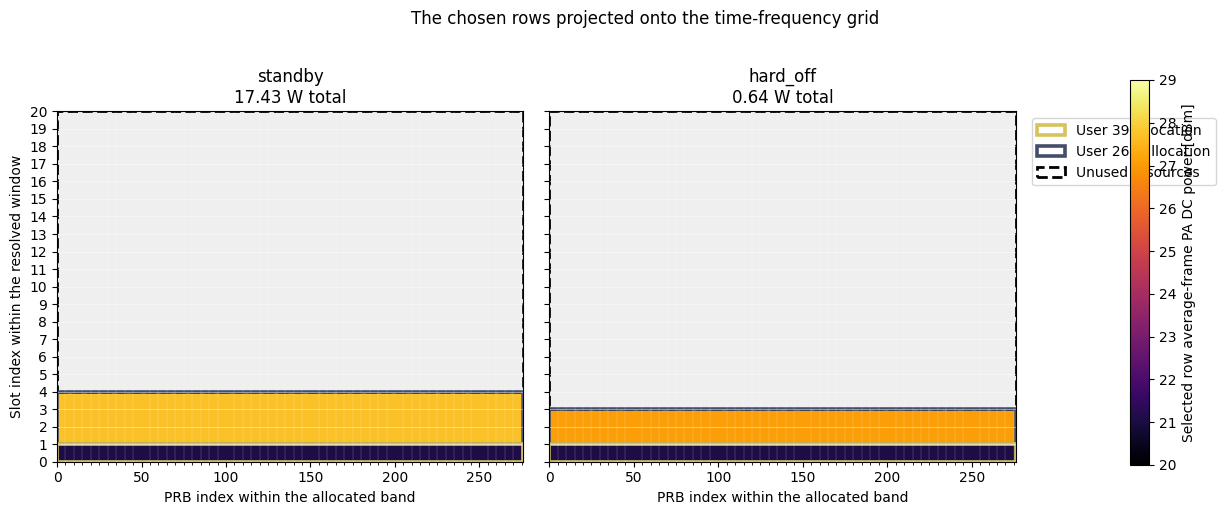

In [18]:
detail_policy_summary_view = build_policy_summary_view_for_bin(
    bin_table_all,
    scenario_order=scenario_order,
    bin_index=DETAIL_BIN,
)
detail_allocation_views = build_allocation_views_for_bin(
    allocation_table_all,
    bin_table_all,
    scenario_order=scenario_order,
    bin_index=DETAIL_BIN,
)

plot_power_heatmaps(
    detail_allocation_views,
    scenario_order,
    detail_policy_summary_view,
)


C:\Users\henry\Documents\Masters Thesis\code\notebooks\helpers\tdma_scheduling_helpers.py:873: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 1))


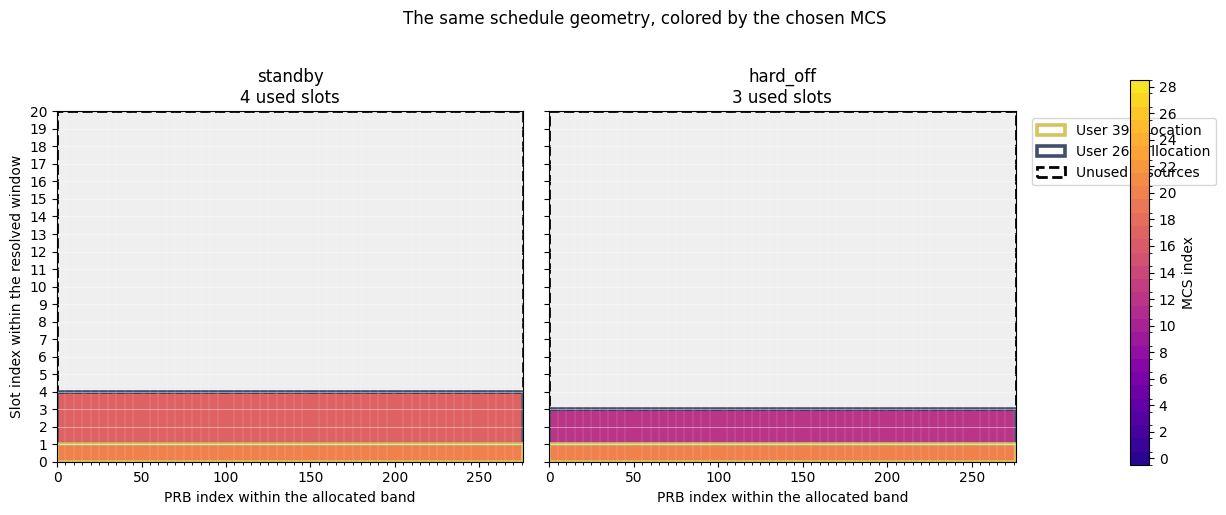

In [19]:
plot_mcs_heatmaps(
    detail_allocation_views,
    scenario_order,
    detail_policy_summary_view,
)


The value of reusing the TDMA heatmaps here is that the day-level result stays connected to the earlier notebook sequence. The day notebook does not need a new visual language. It can reuse the same resource-grid view to show that the scenario gap comes from different selected rows and different slot, PRB, layer, or MCS choices.


## 9. Day Totals and Direct Scenario Differences

After the representative bins, the final step is to return to the day level and summarize what changed over the full run. The table collects the small set of numbers that are most useful for a checkpoint discussion. The figures then show how the scenario totals accumulate over time and, once more than one scenario is loaded, where one scenario departs from another on a bin-by-bin basis.


In [20]:
day_total_summary_table = build_day_total_summary_table(
    bin_table_all,
    scenario_order=scenario_order,
    bin_duration_s=bin_duration_s,
)

display(
    style_day_total_summary_table(
        day_total_summary_table,
        caption="Day-level scenario summary",
    )
)


Scenario,Solved bins,Infeasible bins,Mean total power (W),Peak total power (W),Day energy (Wh),Mean unused slots,Peak requested rate (Mbps)
standby,94,2,25.52,64.15,599.81,3.35,311.11
hard_off,94,2,12.10,62.88,284.29,4.14,311.11


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_cumulative_energy.png


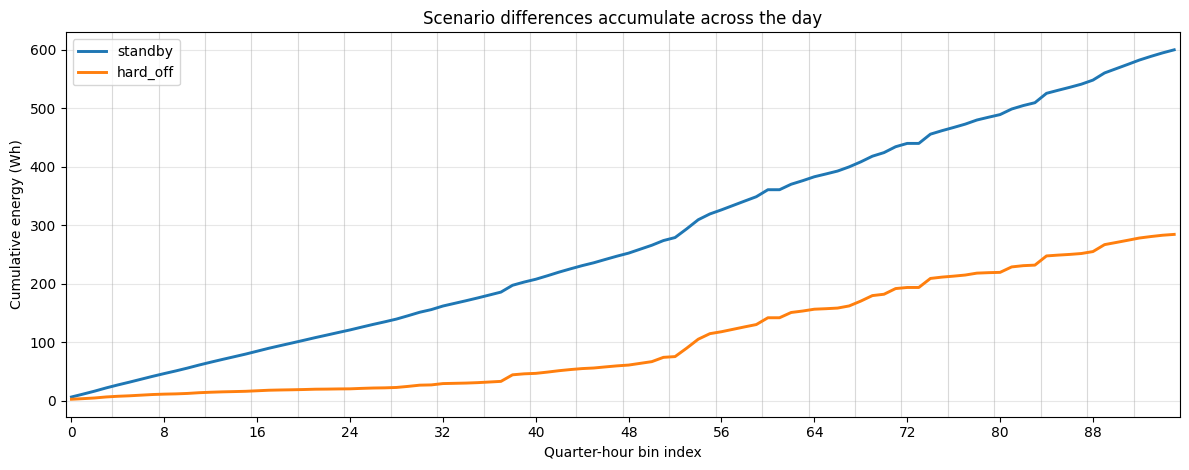

In [21]:
fig, ax = plot_cumulative_day_energy(
    bin_table_all,
    scenario_order=scenario_order,
    bin_duration_s=bin_duration_s,
)
export_doc_figure(fig, "day_results_cumulative_energy.png", DOC_IMG_DIR)
plt.show()


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\day_results_power_delta.png


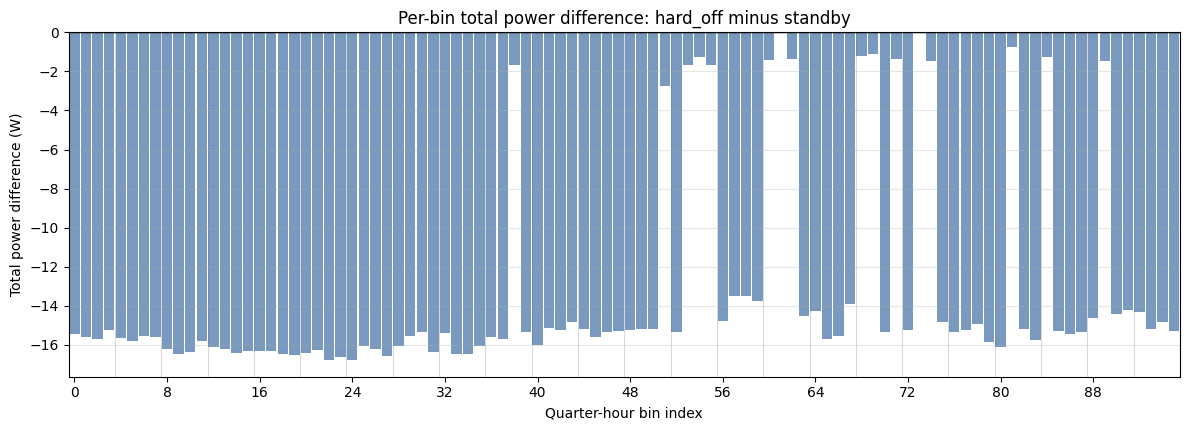

In [22]:
if comparison_available:
    fig, ax = plot_scenario_delta(
        bin_table_all,
        base_scenario=reference_scenario,
        compare_scenario=comparison_scenario,
        value_column="dc_total_w",
        ylabel="Total power difference (W)",
        title=f"Per-bin total power difference: {comparison_scenario} minus {reference_scenario}",
    )
    export_doc_figure(fig, "day_results_power_delta.png", DOC_IMG_DIR)
    plt.show()
else:
    print("Add the standby day-run JSON to enable the per-bin scenario-delta plot.")


## 10. Takeaways

At this checkpoint stage, the notebook already supports the main claims needed for a supervisor update:

- the full-day solver now exports structured bin-level results that are practical to read in a notebook,
- the notebook is ready to compare multiple scenario traces across the same fixed day demand, and the current hard-off export already validates that those traces can be read consistently,
- those differences can be traced back to the exact selected allocations in representative bins,
- the first implementation is therefore strong enough to support the later baseline framing rather than having to invent that framing before the results can be inspected.

The next step is not to add more plots. It is to tighten the scenario definitions and then turn this checkpoint notebook into the final day-results argument.
